In [1]:
%matplotlib inline

In [2]:
# Standard library
import os
import random

# Data
import torch
import numpy as np
from datasets import load_from_disk

# ML
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.utils.data import DataLoader
from torch.optim import AdamW

# NLP
from sentence_transformers import SentenceTransformer, util, InputExample, losses

# Visualization
import matplotlib.pyplot as plt

In [3]:
def load_data(dataset_name):
    # Set train set path
    path = f"data/{dataset_name}"

    # Extract split from the dataset name
    if "train" in dataset_name:
        split = "train"
    elif "val" in dataset_name:
        split = "val"
    elif "test" in dataset_name:
        split = "test"

    # Load train set
    dataset_dict = load_from_disk(path)
    dataset = dataset_dict[split]
    
    # Shuffle train set or val set with seed for reproducibility
    if split == "train" or split == "val":
        dataset = dataset.shuffle(seed=42)

    return dataset

In [4]:
def load_model(model_name):
    model_path = f"./models/{model_name}"
    if not os.path.exists(model_path):
        print(f"Model '{model_name}' not found locally. Downloading...")
        model = SentenceTransformer(model_name)  # Download from Hugging Face
        model.save(model_path)
    else:
        model = SentenceTransformer(model_path)
    print(f"'{model_name}' loaded and ready to use...")

    return model

### Evaluator
- We define an evaluator that computes predictions and evaluation metrics.
- For prediction computation, we do not use a threshold, since we are not defining a “null class” for predictions with similarity below a given threshold.
- Metric computation
    - we use **macro averaging**
    - evaluation metrics considered
        - **accuracy**
        - **precision**
        - **recall**
        - **f1 score**

In [5]:
class MultiMetricEvaluator:
    def __init__(self, dataset, labels, name):
        self.dataset = dataset
        self.labels = labels
        self.name = name

    def __call__(self, model):
        pairs = self._compute_predictions(model)
        acc, prec, rec, f1 = self._compute_metrics(pairs)

        return {"accuracy" : acc, "precision" : prec, "recall" : rec, "f1_score" : f1}
    
    def _compute_predictions(self, model):
        # Compute label embeddings
        label_embeddings = model.encode(self.labels, convert_to_tensor=True)

        results = []
        for sample in self.dataset:
            text = sample['text']
            true_label = sample['label']

            # Compute text embeddings
            text_embedding = model.encode(text, convert_to_tensor=True)

            # Compute the cosine similarity between the text and each label embedding
            similarities = util.cos_sim(text_embedding, label_embeddings)
            
            # Predict the label with the highest similarity
            predicted_label = torch.argmax(similarities).item()

            # Save the pair (predicted label, correct label)
            results.append((predicted_label, true_label))
            
        return results

    def _compute_metrics(self, pairs):
        # Extraction of each pair (predicted label, correct label)
        predictions, true_labels = zip(*pairs)

        # Accuracy
        accuracy = accuracy_score(true_labels, predictions)
        # Use macro for precision, recall ed F1 score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            true_labels,
            predictions,
            average='macro',
            zero_division=0
        )

        return accuracy, precision, recall, f1_score

In [6]:
def test(model, test_set, labels):
    # Initialize test evaluator
    evaluator = MultiMetricEvaluator(test_set, labels, "Test evaluator")

    # Compute metrics on the test set
    metrics = evaluator(model)
    accuracy = metrics["accuracy"]
    precision = metrics["precision"]
    recall = metrics["precision"]
    f1_score = metrics["f1_score"]

    # Print metrics
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1_score}")

### Set a seed for random, torch and cuda

In [7]:
def set_seed(seed):
    # Set the seed for Python's random module
    random.seed(seed)
    # Set the seed for NumPy's random number generator
    np.random.seed(seed)
    # Set a seed for all PyTorch CPU random generators
    torch.manual_seed(seed)
    # Set the seed for CUDA
    torch.cuda.manual_seed_all(seed)
    # Force cuDNN to use deterministic algorithms
    torch.backends.cudnn.deterministic = True
    # Prevent cuDNN from selecting different algorithms based on batch size
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

### Data preparation

##### Simple negative sampling
- For each example in the input dataset, we construct k pairs: the first is the positive pair, while the remaining k−1 are negative pairs. Each pair is wrapped in an InputExample. The function returns a list of InputExample objects.

In [8]:
def simple_negative_sampling(dataset, labels):
    examples = []
    num_classes = len(labels)
    for sample in dataset:
        text = sample["text"]
        true_label = sample["label"]
            
        # Positive pair: the text is paired with the correct label
        examples.append(InputExample(texts=[text, labels[true_label]], label=1.0))
            
        # Negative pairs: the text is paired with all incorrect labels
        for i in range(num_classes):
            if i != true_label:
                examples.append(InputExample(texts=[text, labels[i]], label=0.0))
    
    return examples

### Training
- We define a **Trainer class** that takes training and validation data as input and provides a train method responsible for model training.
- We choose an evaluation metric as the **validation score**, specifically the F1 score.
- The train function implements an **early stopping** mechanism: when no improvement is observed for a number of epochs equal to the patience parameter (i.e., the validation score is no longer improving), training is stopped. The best model is saved whenever a new highest validation score is achieved.
- Loss function: **Contrastive Loss** (https://sbert.net/docs/package_reference/sentence_transformer/losses.html#contrastiveloss)
    - $$Loss \;=\; y \, D^2 \;+\; (1 - y)\,\max\bigl(0,\,m - D\bigr)^2$$
        - $D$ is the distance between the embeddings:
            - in our case, it is given by **cosin distance**: $D = 1−cos(e1​, e2​)$

In [9]:
class Trainer:
    def __init__(self, train_set, val_set, labels):
        self.train_set = train_set
        self.val_set = val_set
        self.labels = labels
        self.model_name = None
        self.output_path = None
        self.train_dataloader = None
        
        self.train_evaluator = MultiMetricEvaluator(self.train_set, self.labels, name="Train Evaluator")

        self.val_evaluator = MultiMetricEvaluator(self.val_set, self.labels, name = "Val Evaluator")

        self.best_f1 = -float("inf")

        self.metrics_history = {
            "train": [],
            "val": []
        }

        self.plots_dir = "plots"

    def set_model_name(self, model_name):
        self.model_name = model_name

    def set_output_path(self, output_path):
        self.output_path = output_path

    def set_train_dataloader(self, train_examples, batch_size):
        self.train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size)

    def get_output_path(self):
        return self.output_path
    
    def get_model_name(self):
        return self.model_name
    
    def get_best_f1(self):
        return self.best_f1

    def train(self, model, num_epochs, learning_rate, warmup_steps, patience):
        loss = losses.ContrastiveLoss(model, margin=0.5)

        epochs_without_improvement = 0

        # Training for n epochs
        for epoch in range(1, num_epochs + 1):
            print(f"Epoch {epoch}/{num_epochs}")

            # Run fit once per epoch
            model.fit(
                train_objectives=[(self.train_dataloader, loss)],
                evaluator=None,
                epochs=1,
                warmup_steps=warmup_steps,
                optimizer_class=AdamW,
                optimizer_params={'lr': learning_rate},
                output_path=None,
                show_progress_bar=True
            )

            # Extract computed metrics
            train_metrics = self.train_evaluator(model)
            val_metrics = self.val_evaluator(model)

            # Select the evaluator score (F1 score in our case)
            train_f1 = train_metrics["f1_score"]
            val_f1 = val_metrics["f1_score"]

            # Store metrics
            self.metrics_history["train"].append(train_metrics)
            self.metrics_history["val"].append(val_metrics)

            # Print evaluation score
            print(f"({self.train_evaluator.name}) Train F1: {train_f1 * 100:.4f}")
            print(f"({self.val_evaluator.name}) Val F1: {val_f1 * 100:.4f}")

            # Early stopping
            if val_f1 > self.best_f1:
                # Update best score
                self.best_f1 = val_f1
                print(f"New best validation score reached! Val F1 = {self.best_f1 * 100:.4f}")
                # Reset counter to restart tracking
                epochs_without_improvement = 0
                # Save the best model found
                if self.output_path:
                    print(f"Saving model to {self.output_path}")
                    model.save(self.output_path)
            else:
                epochs_without_improvement += 1
                print(f"No improvement for {epochs_without_improvement} consecutive epochs.")
                if epochs_without_improvement >= patience:
                    print("Early stopping triggered!")
                    break

        print(f"Training completed. Best validation score = {self.best_f1 * 100:.4f}")

        self._plot_metrics()

    def _plot_metrics(self):
        sub_dir = os.path.join(self.plots_dir, self.model_name)
        os.makedirs(sub_dir, exist_ok=True)
        
        # Extract number of epochs
        epochs = list(range(1, len(self.metrics_history["train"]) + 1))

        # Plot only the F1 score
        train_f1 = [m["f1_score"] for m in self.metrics_history["train"]]
        val_f1   = [m["f1_score"] for m in self.metrics_history["val"]]

        plt.figure()
        plt.plot(epochs, train_f1, label="Train F1")
        plt.plot(epochs, val_f1,   label="Val F1")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.title("F1 score during training")
        plt.legend()
        plt.grid(True)

        filename = "f1_score.png"
        path = os.path.join(sub_dir, filename)
        plt.savefig(path)
        plt.show()
        plt.close()
        print(f"F1 score plot saved to: {path}")

##### Simple mining
- We apply simple negative sampling and proceed to training

In [10]:
def simple_mining(model, train_set, val_set, labels, hyperparameters, model_name):
    # Extract hyperparameters
    lr = hyperparameters["learning rate"]
    bs = hyperparameters["batch size"]
    ws = hyperparameters["warmup steps"]
    epochs = hyperparameters["num epochs"]
    patience = hyperparameters["patience"]

    # Instantiate a generic Trainer
    trainer = Trainer(train_set, val_set, labels)

    # Set model name
    trainer.set_model_name(model_name)

    # Set model output path
    output_path = f"./models/{model_name}"
    trainer.set_output_path(output_path)

    # Data preparation
    train_examples = simple_negative_sampling(train_set, labels)

    # Initialize DataLoader
    trainer.set_train_dataloader(train_examples, batch_size=bs)
    
    # Training
    trainer.train(model, num_epochs=epochs, learning_rate=lr, warmup_steps=ws, patience=patience)

---

### Testing the pretrained model using the original dataset labels
We test the pretrained model to evaluate its performance on our test set extracted from AG News, in order to establish its baseline performance.

In [11]:
# Load test set
test_set = load_data("AgNews_test_1000")

# Load pretrained_model
pretrained_model = load_model("all-mpnet-base-v2")

# Ground-truth labels from the AG News dataset
original_labels = test_set.features["label"].names

# Evaluation using the original labels
test(pretrained_model, test_set, original_labels)

'all-mpnet-base-v2' loaded and ready to use...
Accuracy: 0.589
Precision: 0.5977632110900326
Recall: 0.5977632110900326
F1 Score: 0.5864686679440778


### More descriptive labels than the original dataset labels
The model’s performance with the original labels is very poor. We define more descriptive labels for each class to improve the performance of the pretrained model.

In [12]:
label_0 = "World & Actuality: Politics, Diplomacy, International, Government, Nation"
label_1 = "Sports & Competitions: Players, Teams, Win, Tournament, Ranking"
label_2 = "Business & Finance: Stock Market, Economy, Company, Investment, Debt"
label_3 = "Science & Technology: Research, Devices, Computer Science, Math, Engineering"

labels = [label_0, label_1, label_2, label_3]

##### Testing the pretrained model using the new labels
As we can see, the pretrained model’s performance has improved thanks to more descriptive labels.

In [13]:
test(pretrained_model, test_set, labels)

Accuracy: 0.748
Precision: 0.7583220315532004
Recall: 0.7583220315532004
F1 Score: 0.7387827496944527


### Simple mining fine-tuning

In [14]:
# Load training set and validation set
train_set = load_data("AgNews_train_1000")
val_set = load_data("AgNews_val_250")

In [15]:
hyperparameters = {
    "learning rate" : 2e-5,
    "batch size" : 16,
    "warmup steps" : 100,
    "num epochs" : 10,
    "patience" : 3
}

##### Fine-tuning using the original dataset labels

'all-mpnet-base-v2' loaded and ready to use...
Epoch 1/10


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


(Train Evaluator) Train F1: 91.7678
(Val Evaluator) Val F1: 89.1956
New best validation score reached! Val F1 = 89.1956
Saving model to ./models/all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels
Epoch 2/10


Step,Training Loss


...

(Train Evaluator) Train F1: 99.6956
(Val Evaluator) Val F1: 90.8041
No improvement for 1 consecutive epochs.
Epoch 6/10


Step,Training Loss


(Train Evaluator) Train F1: 99.7958
(Val Evaluator) Val F1: 89.6015
No improvement for 2 consecutive epochs.
Epoch 7/10


Step,Training Loss


(Train Evaluator) Train F1: 99.5917
(Val Evaluator) Val F1: 91.1858
No improvement for 3 consecutive epochs.
Early stopping triggered!
Training completed. Best validation score = 91.5914


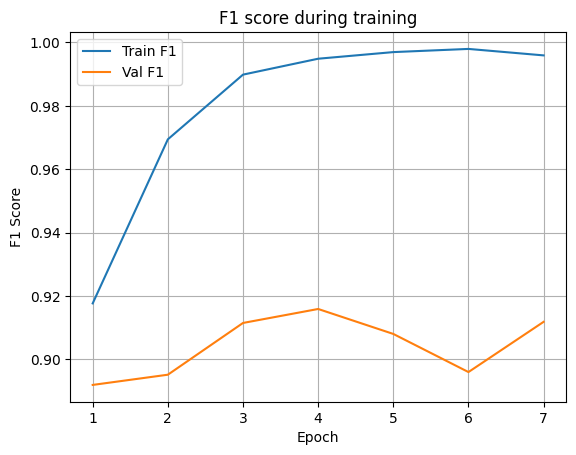

F1 score plot saved to: plots/all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels/f1_score.png


In [16]:
# Load pretrained_model
pretrained_model = load_model("all-mpnet-base-v2")

# Fine-tuning with simple negative mining
simple_mining(pretrained_model, train_set, val_set, original_labels, hyperparameters, "all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels")

##### Testing

In [17]:
fine_tuned_original_labels = load_model("all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels")

print("Model performance:")
test(fine_tuned_original_labels, test_set, labels)

'all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels' loaded and ready to use...
Model performance:
Accuracy: 0.896
Precision: 0.896936863896542
Recall: 0.896936863896542
F1 Score: 0.8956346243002997


##### Fine-tuning using the new descriptive labels

'all-mpnet-base-v2' loaded and ready to use...
Epoch 1/10


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


(Train Evaluator) Train F1: 92.5364
(Val Evaluator) Val F1: 90.7514
New best validation score reached! Val F1 = 90.7514
Saving model to ./models/all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels
Epoch 2/10


Step,Training Loss


...

(Train Evaluator) Train F1: 99.4955
(Val Evaluator) Val F1: 91.1818
No improvement for 1 consecutive epochs.
Epoch 6/10


Step,Training Loss


(Train Evaluator) Train F1: 99.2997
(Val Evaluator) Val F1: 90.8366
No improvement for 2 consecutive epochs.
Epoch 7/10


Step,Training Loss


(Train Evaluator) Train F1: 99.2970
(Val Evaluator) Val F1: 91.2358
No improvement for 3 consecutive epochs.
Early stopping triggered!
Training completed. Best validation score = 92.8367


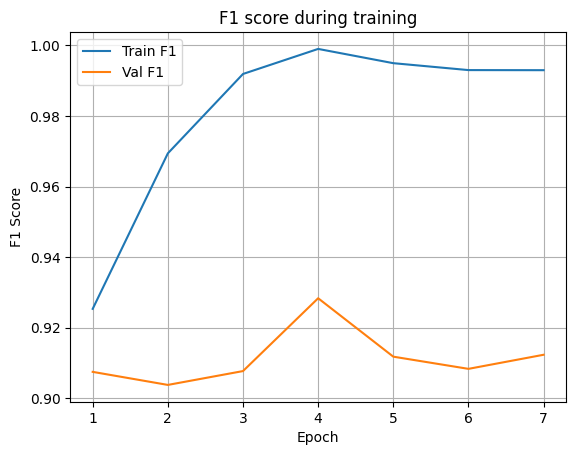

F1 score plot saved to: plots/all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels/f1_score.png


In [18]:
# Load pretrained_model
pretrained_model = load_model("all-mpnet-base-v2")

# Fine-tuning with simple negative mining
simple_mining(pretrained_model, train_set, val_set, labels, hyperparameters, "all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels")

##### Testing

In [19]:
fine_tuned_simple_descriptive_labels = load_model("all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels")

print("Model performance:")
test(fine_tuned_simple_descriptive_labels, test_set, labels)

'all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels' loaded and ready to use...
Model performance:
Accuracy: 0.901
Precision: 0.9013130686269373
Recall: 0.9013130686269373
F1 Score: 0.9009413868315996


### Evaluation of models on the test set
- As we can see, introducing more descriptive labels led to a small improvement in fine-tuning performance.

| Model | Accuracy | Precision | Recall | F1 Score |
|-----------|----------|----------|----------|----------|
| all-mpnet-base-v2 pretrained using original labels    | 0.5890     | 0.5977      | 0.5977     | 0.5864      |
| all-mpnet-base-v2 pretrained using descriptive labels     | 0.7480      | 0.7583     | 0.7583      | 0.7387     |
| all-mpnet-base-v2-agnews-1k-finetuned-simple-original-labels    |  0.8960   |  0.8969    |  0.8969  |   0.8956   |
| all-mpnet-base-v2-agnews-1k-finetuned-simple-descriptive_labels    | 0.9010      | 0.9013      | 0.9013      | 0.9009      |